Exercício 2

In [89]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root

numero_amostras = 100
mu = 0
sigma = 1
X_N = np.random.laplace(mu, sigma, size=numero_amostras)

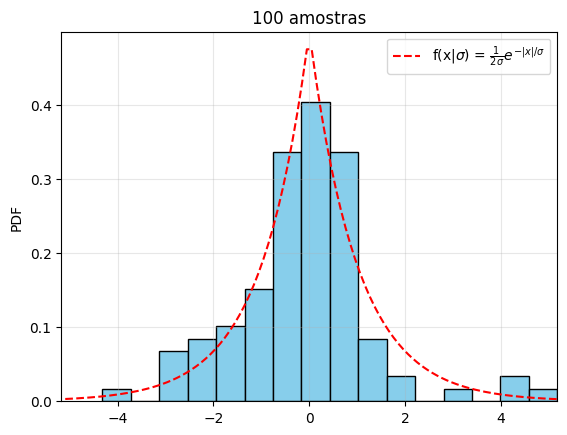

Média real = 0
Variância real = 1

Média amostral: -0.12152071983880473

Método dos momentos - Média estimada = -0.12152
Método dos momentos - Variância estimada = 1.00986

Método da verossimilhança - Média estimada = -0.06613
Método da verossimilhança - Variância estimada = 0.98717



In [90]:
x = np.linspace(-10,10,200)
pdf = (1/(2*sigma))*np.exp(-(np.abs(x)/sigma))
xlim = np.max(np.abs(X_N))
plt.figure()
plt.title(f'{numero_amostras} amostras')
plt.plot(x,pdf,color='red',ls='--',label=r'f(x|$\sigma$) = $\frac{1}{2 \sigma}e^{-|x| / \sigma}$')
plt.grid(alpha=0.3)
plt.hist(X_N,density=True,bins='auto',edgecolor='black',color='skyblue')
plt.legend()
plt.ylabel('PDF')
plt.xlim(-xlim,xlim)
plt.show()

print('Média real = 0')
print('Variância real = 1\n')

media_amostral = np.mean(X_N)
print('Média amostral:', media_amostral)

#Método dos Momentos
m1 = np.mean(X_N)
m2 = np.mean((X_N**2))

def F(theta):
    mu, b = theta
    return [mu - m1,mu**2 + 2*b**2 - m2]

sol = root(F, [0, 1])
mu_hat, b_hat = sol.x

print(f'\nMétodo dos momentos - Média estimada = {mu_hat:.5f}')
print(f'Método dos momentos - Variância estimada = {b_hat:.5f}\n')

#Método da Verossimilhança
sigmas = np.linspace(0.1,2,500)
medias = np.linspace(-1,1,500)
L = np.zeros((len(sigmas),len(medias)))
for l in range(len(medias)):
    for j in range(len(sigmas)):
        L[j][l] = - np.log((2*sigmas[j]))*len(X_N) - np.sum(np.abs(X_N-medias[l])) / sigmas[j]

theta_max = np.unravel_index(np.argmax(L), L.shape)
Var = sigmas[theta_max[0]]
med = medias[theta_max[1]]

print(f'Método da verossimilhança - Média estimada = {med:.5f}')
print(f'Método da verossimilhança - Variância estimada = {Var:.5f}\n')